# Nairobi City County Own Source Revenue Business Intelligence System

# Notebook 02: Exploratory Data Analysis (EDA)

## Author
Erastus Okomo

### Project
Nairobi City County Own Source Revenue Business Intelligence System

## Objective

The objective of this notebook is to explore the cleaned Own Source Revenue dataset to identify trends, patterns, key revenue contributors, and insights that can support decision-making within Nairobi City County.

# 1. Import Libraries

This section imports all libraries required for exploratory data analysis and visualization.

In [1]:
# ===========================================================
# IMPORT LIBRARIES
# ===========================================================

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", None)
pd.options.display.float_format = "{:,.2f}".format

sns.set_style("whitegrid")

# 2. Load Clean Dataset

The cleaned dataset generated during the ETL process is loaded for exploratory data analysis.

In [2]:
# ===========================================================
# LOAD CLEAN DATASET
# ===========================================================

file_path = "../data/processed/OSR2025JUNE30_Clean.xlsx"

df = pd.read_excel(file_path)

df.head()

,Revenue_Stream,Q1,Q2,Q3,Q4,Total,Calculated_Total
0,Land Rates,"196,074,592.42","142,363,884.10","1,974,387,400.91","974,143,361.24","3,286,969,238.67","3,286,969,238.67"
1,Parking fees (total),"403,102,547.00","415,717,240.00","624,117,208.00","467,616,505.00","1,910,553,500.00","1,910,553,500.00"
2,Unified Business permit,"268,881,225.00","322,159,358.00","1,363,055,364.00","644,656,753.00","2,598,752,700.00","2,598,752,700.00"
3,Plans and Inspections (Building Permits),"434,454,160.00","421,195,656.00","316,879,305.00","286,453,495.00","1,458,982,616.00","1,458,982,616.00"
4,Billboards and advertisements,"96,830,108.00","188,022,729.00","205,184,225.00","153,075,885.00","643,112,947.00","643,112,947.00"


In [3]:
# ===========================================================
# TOTAL REVENUE
# ===========================================================

total_revenue = df["Total"].sum()

print("="*50)
print("TOTAL OWN SOURCE REVENUE")
print("="*50)

print(f"KES {total_revenue:,.2f}")

TOTAL OWN SOURCE REVENUE
KES 13,654,721,017.37


In [4]:
top_stream = df.loc[df["Total"].idxmax()]

print(top_stream)

Revenue_Stream           Land Rates
Q1                   196,074,592.42
Q2                   142,363,884.10
Q3                 1,974,387,400.91
Q4                   974,143,361.24
Total              3,286,969,238.67
Calculated_Total   3,286,969,238.67
Name: 0, dtype: object


In [5]:
lowest_stream = df.loc[df["Total"].idxmin()]

print(lowest_stream)

Revenue_Stream      Fire Inspection Certificates
Q1                                    761,000.00
Q2                                    566,500.00
Q3                                  2,754,000.00
Q4                                  1,285,000.00
Total                               5,366,500.00
Calculated_Total                    5,366,500.00
Name: 6, dtype: object


In [9]:
top10 = (
    df
    .sort_values("Total", ascending=False)
    .head(10)
)

top10

,Revenue_Stream,Q1,Q2,Q3,Q4,Total,Calculated_Total
0,Land Rates,"196,074,592.42","142,363,884.10","1,974,387,400.91","974,143,361.24","3,286,969,238.67","3,286,969,238.67"
2,Unified Business permit,"268,881,225.00","322,159,358.00","1,363,055,364.00","644,656,753.00","2,598,752,700.00","2,598,752,700.00"
1,Parking fees (total),"403,102,547.00","415,717,240.00","624,117,208.00","467,616,505.00","1,910,553,500.00","1,910,553,500.00"
3,Plans and Inspections (Building Permits),"434,454,160.00","421,195,656.00","316,879,305.00","286,453,495.00","1,458,982,616.00","1,458,982,616.00"
9,Other Incomes/Unallocated,"262,110,272.28","212,776,330.58","237,211,004.32","239,130,607.02","951,228,214.20","951,228,214.20"
5,House and Stall Rent,"109,158,566.00","180,840,370.00","147,219,979.00","337,569,050.00","774,787,965.00","774,787,965.00"
4,Billboards and advertisements,"96,830,108.00","188,022,729.00","205,184,225.00","153,075,885.00","643,112,947.00","643,112,947.00"
13,Mama Lucy,"133,213,418.00","169,692,979.00","138,099,147.00","134,383,277.00","575,388,821.00","575,388,821.00"
12,Mbagathi,"140,644,661.00","131,439,322.00","84,215,086.50","104,311,777.00","460,610,846.50","460,610,846.50"
10,Liquor Board Revenue,"76,489,325.00","73,105,351.00","90,546,930.00","98,450,355.00","338,591,961.00","338,591,961.00"


In [10]:
df["Contribution (%)"] = (
    df["Total"] /
    df["Total"].sum()
) * 100

In [11]:
df[
    ["Revenue_Stream",
     "Total",
     "Contribution (%)"]
].sort_values(
    "Contribution (%)",
    ascending=False
)

,Revenue_Stream,Total,Contribution (%)
0,Land Rates,"3,286,969,238.67",24.07
2,Unified Business permit,"2,598,752,700.00",19.03
1,Parking fees (total),"1,910,553,500.00",13.99
3,Plans and Inspections (Building Permits),"1,458,982,616.00",10.68
9,Other Incomes/Unallocated,"951,228,214.20",6.97
5,House and Stall Rent,"774,787,965.00",5.67
4,Billboards and advertisements,"643,112,947.00",4.71
13,Mama Lucy,"575,388,821.00",4.21
12,Mbagathi,"460,610,846.50",3.37
10,Liquor Board Revenue,"338,591,961.00",2.48


In [12]:
quarter_totals = df[
    ["Q1","Q2","Q3","Q4"]
].sum()

quarter_totals

Q1   2,229,181,659.70
Q2   2,433,988,379.68
Q3   5,382,672,801.73
Q4   3,608,878,176.26
dtype: float64

# 3. Top Revenue Streams

This visualization ranks revenue streams according to the total revenue collected during the financial year.

The objective is to identify the County's major revenue sources and those requiring policy attention.

Text(0.5, 0, 'Revenue (KES Billions)')

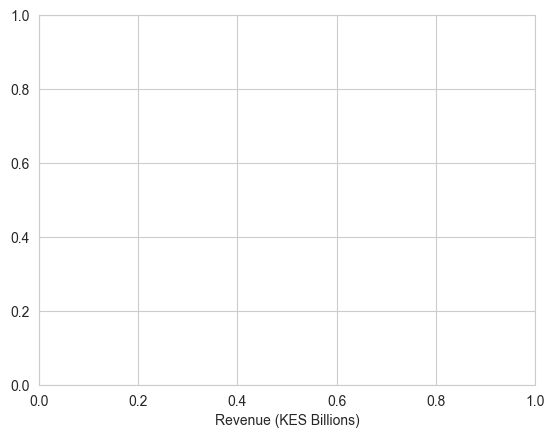

In [32]:
from matplotlib.ticker import FuncFormatter


ax.xaxis.set_major_formatter(
    FuncFormatter(lambda x, pos: f'{x/1e9:.1f} B')
)

plt.xlabel("Revenue (KES Billions)")

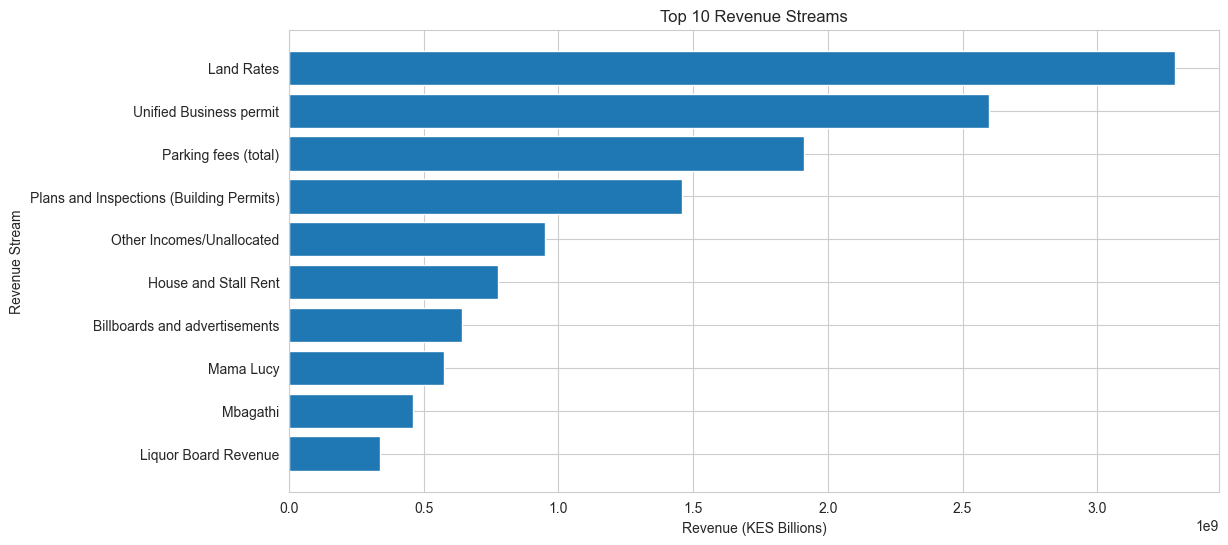

In [31]:
# ===========================================================
# TOP 10 REVENUE STREAMS
# ===========================================================

top10 = (
    df
    .sort_values("Total", ascending=False)
    .head(10)
)

ax.xaxis.set_major_formatter(
    FuncFormatter(lambda x, pos: f'{x/1e9:.1f} B')
)
plt.figure(figsize=(12,6))

plt.barh(
    top10["Revenue_Stream"],
    top10["Total"]
)

plt.xlabel("Revenue (KES Billions)")

plt.ylabel("Revenue Stream")

plt.title("Top 10 Revenue Streams")

plt.gca().invert_yaxis()

plt.show()

# Executive Summary KPIs

The following KPIs provide a high-level overview of the County's Own Source Revenue performance for FY 2024/25.

In [14]:
# ==========================================================
# KEY PERFORMANCE INDICATORS
# ==========================================================

total_revenue = df["Total"].sum()

number_of_streams = df["Revenue_Stream"].count()

average_revenue = df["Total"].mean()

highest_stream = df.loc[df["Total"].idxmax(), "Revenue_Stream"]

highest_revenue = df["Total"].max()

lowest_stream = df.loc[df["Total"].idxmin(), "Revenue_Stream"]

lowest_revenue = df["Total"].min()

In [15]:
print("="*60)
print("EXECUTIVE KPI SUMMARY")
print("="*60)

print(f"Total Own Source Revenue : KES {total_revenue:,.2f}")

print(f"Revenue Streams          : {number_of_streams}")

print(f"Average Revenue          : KES {average_revenue:,.2f}")

print(f"Highest Revenue Stream   : {highest_stream}")

print(f"Highest Revenue          : KES {highest_revenue:,.2f}")

print(f"Lowest Revenue Stream    : {lowest_stream}")

print(f"Lowest Revenue           : KES {lowest_revenue:,.2f}")

EXECUTIVE KPI SUMMARY
Total Own Source Revenue : KES 13,654,721,017.37
Revenue Streams          : 16
Average Revenue          : KES 853,420,063.59
Highest Revenue Stream   : Land Rates
Highest Revenue          : KES 3,286,969,238.67
Lowest Revenue Stream    : Fire Inspection Certificates
Lowest Revenue           : KES 5,366,500.00


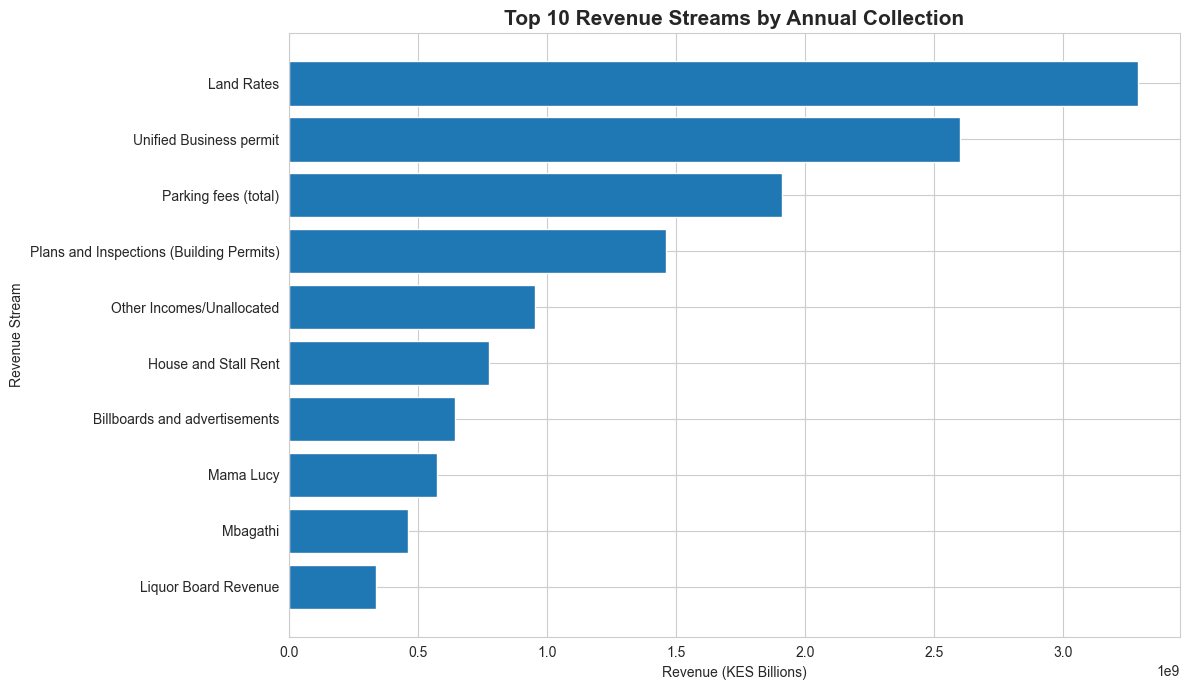

In [34]:
# ==========================================================
# TOP TEN REVENUE STREAMS
# ==========================================================

top10 = (
    df
    .sort_values("Total", ascending=False)
    .head(10)
)

ax.xaxis.set_major_formatter(
    FuncFormatter(lambda x, pos: f'{x/1e9:.1f} B'))
        
plt.figure(figsize=(12,7))

bars = plt.barh(
    top10["Revenue_Stream"],
    top10["Total"]
)

plt.title(
    "Top 10 Revenue Streams by Annual Collection",
    fontsize=15,
    fontweight="bold"
)

plt.xlabel("Revenue (KES Billions)")
plt.ylabel("Revenue Stream")

plt.gca().invert_yaxis()

plt.tight_layout()

plt.show()

## Observation

The chart ranks the ten highest-performing revenue streams during FY 2024/25.

## Interpretation

The County relies heavily on a small number of revenue streams to generate most of its Own Source Revenue.

## Recommendation

Management should continue strengthening compliance in the highest-performing revenue streams while identifying strategies to improve revenue collection from lower-performing streams to reduce dependence on a few sources.

In [17]:
quarter_totals = (
    df[["Q1", "Q2", "Q3", "Q4"]]
    .sum()
)

quarter_totals

Q1   2,229,181,659.70
Q2   2,433,988,379.68
Q3   5,382,672,801.73
Q4   3,608,878,176.26
dtype: float64

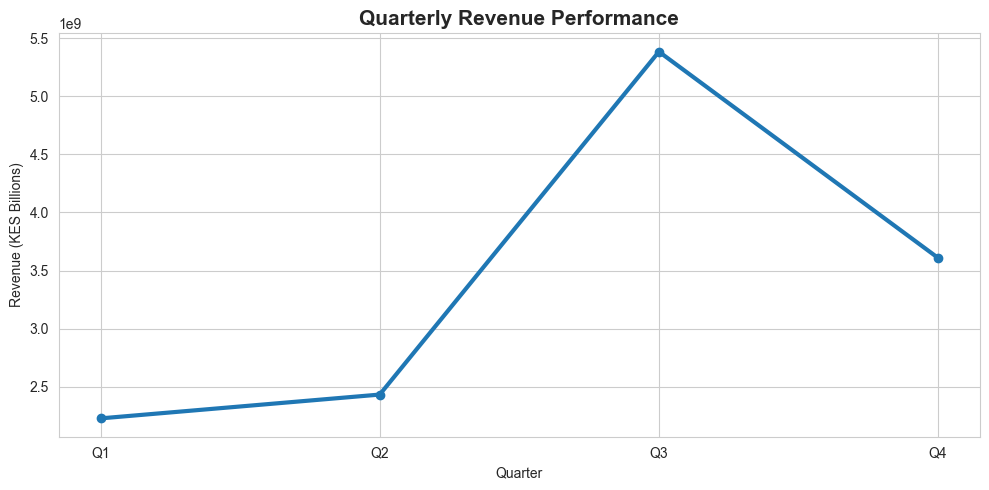

In [36]:
ax.xaxis.set_major_formatter(
    FuncFormatter(lambda x, pos: f'{x/1e9:.1f} B'))
plt.figure(figsize=(10,5))

plt.plot(
    quarter_totals.index,
    quarter_totals.values,
    marker="o",
    linewidth=3
)

plt.title(
    "Quarterly Revenue Performance",
    fontsize=15,
    fontweight="bold"
)

plt.xlabel("Quarter")
plt.ylabel("Revenue (KES Billions)")

plt.grid(True)

plt.tight_layout()

plt.show()

## Observation
Revenue collections increased steadily from Q1 to Q3 before declining slightly in Q4.

## Interpretation 
This pattern may reflect seasonal variations in revenue collection, the timing of billing cycles, or enhanced enforcement efforts during the middle of the financial year.

## Recommendation
The County should investigate the factors contributing to stronger-performing quarters and replicate those strategies in weaker periods.

## Which Revenue Streams Contribute Most to Total Revenue?

In [20]:
# ==========================================================
# REVENUE CONTRIBUTION
# ==========================================================

contribution = (
    df[["Revenue_Stream", "Total", "Contribution (%)"]]
    .sort_values("Contribution (%)", ascending=False)
)

contribution.head(10)

,Revenue_Stream,Total,Contribution (%)
0,Land Rates,"3,286,969,238.67",24.07
2,Unified Business permit,"2,598,752,700.00",19.03
1,Parking fees (total),"1,910,553,500.00",13.99
3,Plans and Inspections (Building Permits),"1,458,982,616.00",10.68
9,Other Incomes/Unallocated,"951,228,214.20",6.97
5,House and Stall Rent,"774,787,965.00",5.67
4,Billboards and advertisements,"643,112,947.00",4.71
13,Mama Lucy,"575,388,821.00",4.21
12,Mbagathi,"460,610,846.50",3.37
10,Liquor Board Revenue,"338,591,961.00",2.48


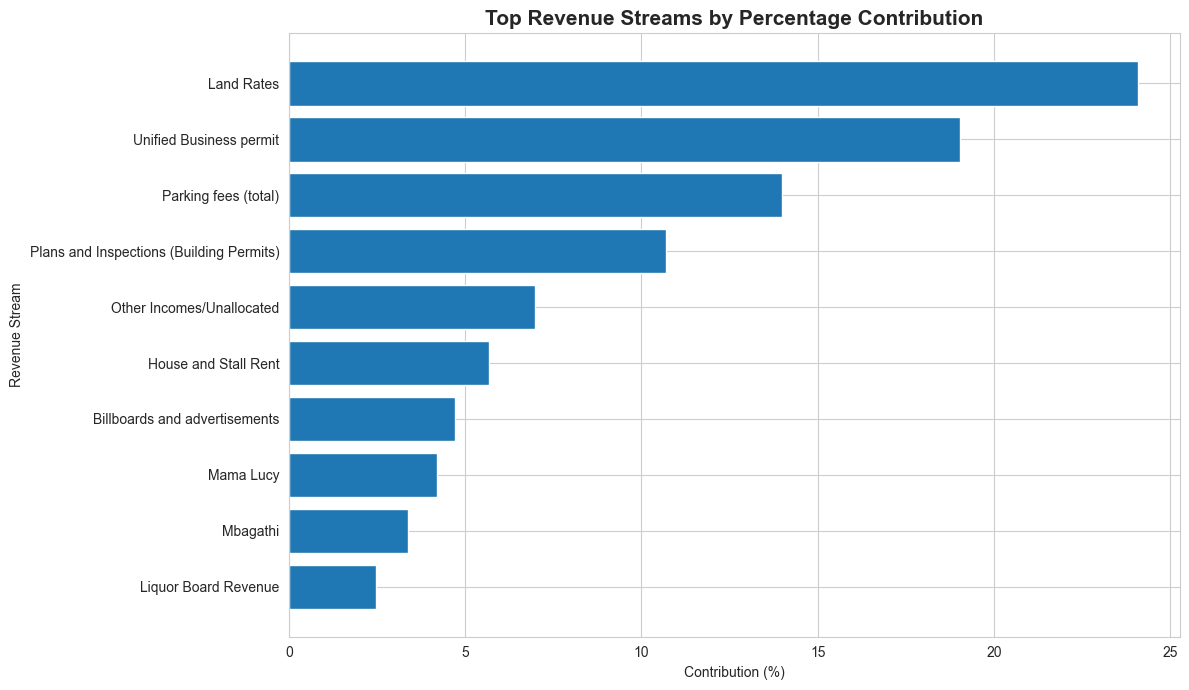

In [21]:
plt.figure(figsize=(12,7))

plt.barh(
    contribution["Revenue_Stream"][:10],
    contribution["Contribution (%)"][:10]
)

plt.title(
    "Top Revenue Streams by Percentage Contribution",
    fontsize=15,
    fontweight="bold"
)

plt.xlabel("Contribution (%)")
plt.ylabel("Revenue Stream")

plt.gca().invert_yaxis()

plt.tight_layout()

plt.show()

## Recommendation
The County should maintain strong compliance and enforcement mechanisms for high-contributing revenue streams while expanding and strengthening lower-performing revenue sources to improve revenue diversification.

# Revenue Distribution (Pareto Analysis)
## Prepare the Data

In [22]:
pareto = (
    df[["Revenue_Stream", "Total"]]
    .sort_values("Total", ascending=False)
)

pareto["Cumulative Revenue"] = pareto["Total"].cumsum()

pareto["Cumulative Percentage"] = (
    pareto["Cumulative Revenue"] /
    pareto["Total"].sum()
) * 100

pareto.head()

,Revenue_Stream,Total,Cumulative Revenue,Cumulative Percentage
0,Land Rates,"3,286,969,238.67","3,286,969,238.67",24.07
2,Unified Business permit,"2,598,752,700.00","5,885,721,938.67",43.10
1,Parking fees (total),"1,910,553,500.00","7,796,275,438.67",57.10
3,Plans and Inspections (Building Permits),"1,458,982,616.00","9,255,258,054.67",67.78
9,Other Incomes/Unallocated,"951,228,214.20","10,206,486,268.87",74.75


## Build the Pareto Chart

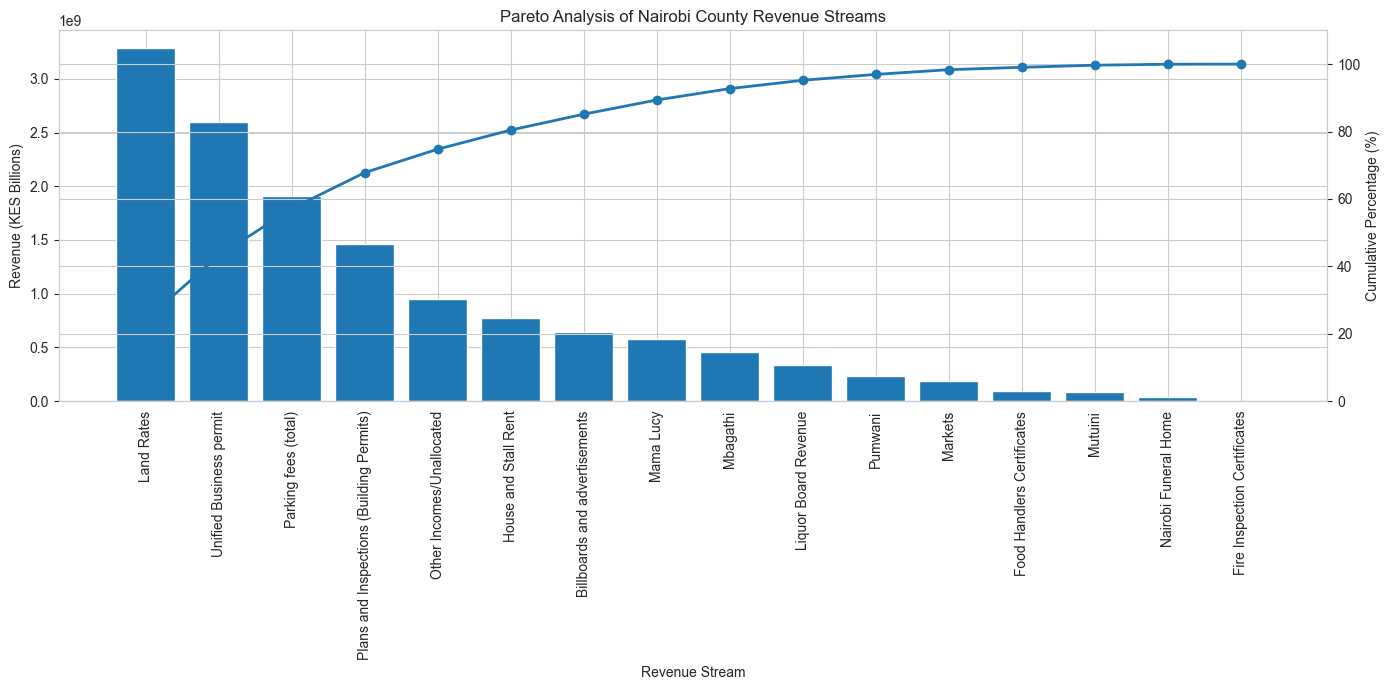

In [37]:
# ==========================================================
# PARETO CHART
# ==========================================================

fig, ax1 = plt.subplots(figsize=(14,7))

# Bar chart
ax1.bar(
    pareto["Revenue_Stream"],
    pareto["Total"]
)

ax.xaxis.set_major_formatter(
    FuncFormatter(lambda x, pos: f'{x/1e9:.1f} B'))
ax1.set_ylabel("Revenue (KES Billions)")
ax1.set_xlabel("Revenue Stream")

# Rotate labels
plt.xticks(rotation=90)

# Secondary axis
ax2 = ax1.twinx()

ax2.plot(
    pareto["Revenue_Stream"],
    pareto["Cumulative Percentage"],
    marker="o",
    linewidth=2
)

ax2.set_ylabel("Cumulative Percentage (%)")
ax2.set_ylim(0,110)

plt.title("Pareto Analysis of Nairobi County Revenue Streams")

plt.tight_layout()

plt.show()

## Which quarter contributed most

In [25]:
quarter_summary = pd.DataFrame({
    "Revenue": quarter_totals
})

quarter_summary["Contribution (%)"] = (
    quarter_summary["Revenue"] /
    quarter_summary["Revenue"].sum()
) * 100

quarter_summary

,Revenue,Contribution (%)
Q1,"2,229,181,659.70",16.33
Q2,"2,433,988,379.68",17.83
Q3,"5,382,672,801.73",39.42
Q4,"3,608,878,176.26",26.43


## Are Quarterly Revenues Evenly Distributed?

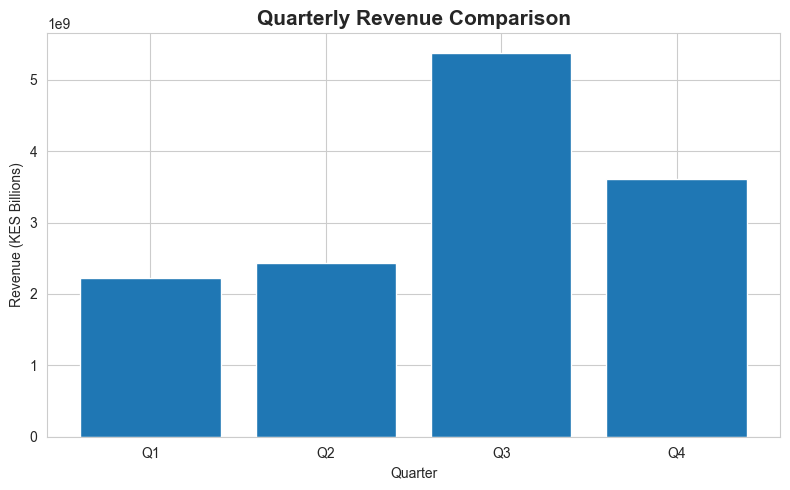

In [39]:
plt.figure(figsize=(8,5))

plt.bar(
    quarter_summary.index,
    quarter_summary["Revenue"]
)

ax.xaxis.set_major_formatter(
    FuncFormatter(lambda x, pos: f'{x/1e9:.1f} B'))
plt.title(
    "Quarterly Revenue Comparison",
    fontsize=15,
    fontweight="bold"
)

plt.xlabel("Quarter")
plt.ylabel("Revenue (KES Billions)")

plt.tight_layout()

plt.show()